In [2]:
import sys
sys.path.append('../')
from utils.MultiLabelPredictor import MultilabelPredictor
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, hamming_loss

/home/massimo/Documents/stage/signature_inference/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### function the evaluate the two predictions

In [3]:
def evaluate(pred, true):
    pred = pred.values.astype(bool).flatten()
    true = true.values.astype(bool).flatten()
    return {
        "F1": f1_score(true.flatten(), pred.flatten()),
        "Precision": precision_score(true.flatten(), pred.flatten()),
        "Recall": recall_score(true.flatten(), pred.flatten()),
        "Accuracy": accuracy_score(true.flatten(), pred.flatten()),
        "HammingLoss": hamming_loss(true.flatten(), pred.flatten())
    }
def sample_percentage_accuracy(pred, true):
    xor = pred == true
    return xor.sum(axis=1)/29

def compare_signature_precision_accuracy(predictions, true, names):
    data = []

    for col in true.columns:
        y_true = true[col]

        for pred, label in zip(predictions, names):
            y_pred = pred[col]
            precision = f1_score(y_true, y_pred, zero_division=0)
            accuracy = accuracy_score(y_true, y_pred)
            data.append([col, label, precision, accuracy])

    df = pd.DataFrame(data, columns=['Signature', 'Model', 'F1-score', 'Accuracy'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    for ax, metric in zip(axes, ['F1-score', 'Accuracy']):
        pivot = df.pivot(index='Signature', columns='Model', values=metric)
        pivot.plot(kind='bar', ax=ax, ylim=(0, 1), rot=90)
        ax.set_title(f'{metric} per Signature')
        ax.set_ylabel(metric)
        ax.legend(loc='lower right')

    plt.tight_layout()
    plt.show()


In [4]:
sampling_size = '0.03'

## Importing the ground truth

In [5]:
gt = pd.read_csv('../simulations/ground_truth/bin_exposures.csv',index_col=0)

## Generating the prediction with the LightGBMXT model

In [6]:
sampling_name = f'trinucleotides_counts_sampling_{sampling_size}'
new_base_path = f'../models/saved/Predictor-{sampling_size}'

predictor = MultilabelPredictor.load(new_base_path)
pred_mutation_count = pd.read_csv(f'../simulations/data2/run_1/{sampling_name}.csv', index_col=0)
# aggiorna i path per ogni label
for label in predictor.labels:
    predictor.predictors[label] = os.path.join(new_base_path, f'Predictor_{label}')
    
prediction = predictor.predict(pred_mutation_count)

Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


Predicting with TabularPredictor for label: S1 (SBS1 - 0.99) ...


Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


Predicting with TabularPredictor for label: S2 (SBS2 - 0.99) ...


Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


...

Predicting with TabularPredictor for label: S27 (SBS88 - 0.92) ...


Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


Predicting with TabularPredictor for label: S28 (SBS92 - 0.95) ...


Found 1 mismatches between original and current metadata:
	INFO: AutoGluon Python micro version mismatch (original=3.10.15, current=3.10.12)


Predicting with TabularPredictor for label: S29 (SBS97 - 0.95) ...


## SigProfileAssignment predictions

In [ ]:
sig_profiler_assignment = pd.read_csv(f'../results/sigProfilerAssignment/spa_{sampling_name}/Assignment_Solution_Activities.txt', sep='\t', index_col=0)
bool_sig_profiler_assignment = pd.DataFrame((sig_profiler_assignment.values > 0).astype(bool), index=sig_profiler_assignment.index, columns=sig_profiler_assignment.columns)

## MuSiCal

In [ ]:
from models.MuSiCal.musical.refit import refit
X = pd.read_csv(f'../simulations/sigprofilerextractordata/{sampling_name}.txt', sep='\t', index_col=0)
W = pd.read_csv('../simulations/ground_truth/signatures_spa.txt', sep='\t', index_col=0)
if not os.path_exists('../results/musical/musical_preidction_{samglin_name.txt}'):
    E = refit(X, W)
    musical_df = pd.DataFrame(E[0])
    musical_df.to_csv('../results/musical/musical_preidction_{samglin_name.txt}')
else:
    musical_df = pd.read_csv('../results/musical/musical_preidction_{samglin_name.txt}', sep='\t', index_col=0)

In [9]:
bool_musical_df = pd.DataFrame((musical_df.values > 0).astype(bool), index=musical_df.index, columns=musical_df.columns).T

## Conparison graphs

In [10]:
print(evaluate(prediction, gt))
print(evaluate(bool_sig_profiler_assignment, gt))
print(evaluate(bool_musical_df, gt))

{'F1': 0.749000667746037, 'Precision': 0.79149187078315, 'Recall': 0.7108392943954441, 'Accuracy': 0.7911127774045534, 'HammingLoss': 0.20888722259544656}


ValueError: Found input variables with inconsistent numbers of samples: [525451, 145000]

In [ ]:
accuracy_per_sample = sample_percentage_accuracy(prediction, gt)
print(f'mean accuracy: {np.mean(accuracy_per_sample)}')
accuracy_per_sample = sample_percentage_accuracy(bool_sig_profiler_assignment, gt)
print(f'mean accuracy: {np.mean(accuracy_per_sample)}')
accuracy_per_sample = sample_percentage_accuracy(bool_musical_df, gt)
print(f'mean accuracy: {np.mean(accuracy_per_sample)}')

mean accuracy: 0.7820206896551724
mean accuracy: 0.6325448275862069
mean accuracy: 0.6904206896551724


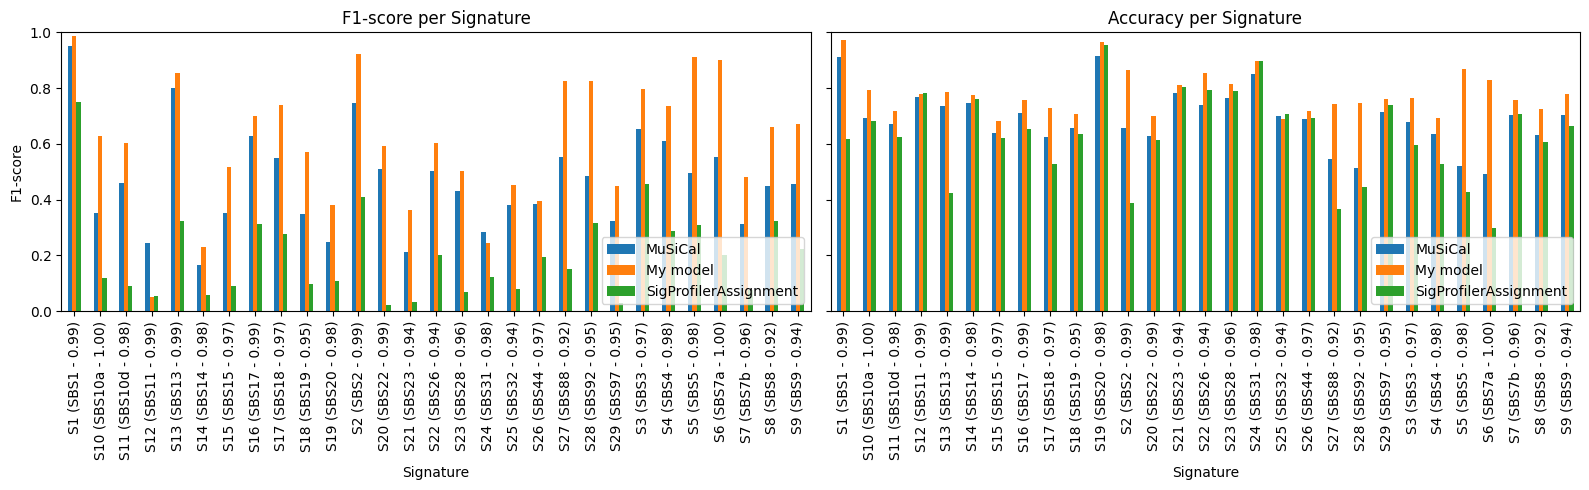

In [ ]:
compare_signature_precision_accuracy([prediction, bool_sig_profiler_assignment, bool_musical_df], gt, ['My model','SigProfilerAssignment', 'MuSiCal'])